In [ ]:
%run ./load_local.py -w

In [25]:
from geolayer.layer import vector_layer, raster_layer, composite_layer
from geolayer.api import redisAPI

file_format = 'png8'

test_tiles_url = []

# Print the ful url of a list of tiles (z,x,y) for a layer and stores the corresponding XML for 1 year
def tiles_print(layer, tiles, file_format=file_format):
    global test_tiles_url
    
    url = layer.tileUrl(file_format=file_format)
    
    xml = layer.xml()
    code = redisAPI.redisStore(xml, expire=60 * 60 * 24 * 365)
    
    for t in tiles:
        tile_url = url.replace('{z}',str(t[0])).replace('{x}',str(t[1])).replace('{y}',str(t[2]))
        test_tiles_url.append(tile_url)
        print(tile_url)

### 1: VectorLayer - Shapefile - NUTS0

In [26]:
import plotly.express as px

vlayer = vector_layer.VectorLayer.file('/data/NUTS_RG_03M_2021_4326_0.shp') #, epsg=4326, proj='+init=epsg:4326')

symbol = [
            [
               ["PolygonSymbolizer", "fill", 'FILL-COLOR'],
               ["PolygonSymbolizer", "fill-opacity", 0.8],
               ["LineSymbolizer", "stroke", "#000000"],
               ["LineSymbolizer", "stroke-width", 1.0]
            ]
]

symbol = [
              [('PolygonSymbolizer', 'fill', 'COLOR'),
               ('PolygonSymbolizer', 'fill-opacity', '1.0'),
               ('LineSymbolizer', 'stroke', '#000000'),
               ('LineSymbolizer', 'stroke-width', '0.0')],
              [('MarkersSymbolizer', 'file', '/symbols/material-design-icons/svg/filled/church.svg'),
                ('MarkersSymbolizer', 'fill', 'COLOR'),
                ('MarkersSymbolizer', 'fill-opacity', '1.0'),
                ('MarkersSymbolizer', 'stroke', '#000000'),
                ('MarkersSymbolizer', 'stroke-width', '1'),
                ('MarkersSymbolizer', 'stroke-opacity', '1.0'),
                ('MarkersSymbolizer', 'width', '18'),
                ('MarkersSymbolizer', 'height', '26'),
                ('MarkersSymbolizer', 'placement', 'line'),
                ('MarkersSymbolizer', 'offset', -20),
                ('MarkersSymbolizer', 'spacing', 20),
                ('MarkersSymbolizer', 'allow-overlap', 'true'),]
]

legend = vlayer.legendCategories('CNTR_CODE', px.colors.qualitative.Dark24, symbol=symbol, interpolate=False)

tiles_print(vlayer, [ (7,65,43), (9,276,183), (11,1134,760)])

https://tilegeo.azurewebsites.net/dts/tile/f79e108e04255d0f444847b4cc1ee306/7/65/43.png8
https://tilegeo.azurewebsites.net/dts/tile/f79e108e04255d0f444847b4cc1ee306/9/276/183.png8
https://tilegeo.azurewebsites.net/dts/tile/f79e108e04255d0f444847b4cc1ee306/11/1134/760.png8


### 2: VectorLayer - Shapefile - FaoZones

In [27]:
vlayer = vector_layer.VectorLayer.file('/data/World_Fao_Zones.shp')

symbol = [
            [
               ['PolygonSymbolizer', 'fill', '#5588ff'],
               ['LineSymbolizer',    'stroke', '#000000'],
               ['LineSymbolizer',    'stroke-width', 1.6],
               ['LineSymbolizer',    'stroke-dasharray', 'none'],
               ['TextSymbolizer',    'face-name', 'DejaVu Sans Book'],
               ['TextSymbolizer',    'elem-value', '[zone]'],
               ['TextSymbolizer',    'halo-radius', 2.0],
               ['TextSymbolizer',    'size', 31.0],
               ['TextSymbolizer',    'allow-overlap', 'true'],
               ['TextSymbolizer',    'placement', 'interior'],
            ],
]

vlayer.symbologyClear()
vlayer.symbologyAdd(symbol=symbol)

tiles_print(vlayer, [ (5,13,13), (5,15,10), (10,538,377)])

https://tilegeo.azurewebsites.net/dts/tile/8501bd31e250091e0b1abbc8d57488e0/5/13/13.png8
https://tilegeo.azurewebsites.net/dts/tile/8501bd31e250091e0b1abbc8d57488e0/5/15/10.png8
https://tilegeo.azurewebsites.net/dts/tile/8501bd31e250091e0b1abbc8d57488e0/10/538/377.png8


### 3: VectorLayer - Geopackage - IsleofMan Buildings

In [28]:
vlayer = vector_layer.VectorLayer.file('/data/IsleofMan.gpkg', layer='31311023') #, epsg=4258, proj='+init=epsg:4258')

symbol = [
            [
               ["PolygonSymbolizer", "fill", 'FILL-COLOR'],
               ["PolygonSymbolizer", "fill-opacity", 0.8],
               ["LineSymbolizer", "stroke", "#000000"],
               ["LineSymbolizer", "stroke-width", 1.0]
            ]
]

legend = vlayer.legendSingle(symbol=vector_layer.VectorLayer.symbolChange(symbol, fillColor='#00aa00'))

tiles_print(vlayer, [ (12,1995,1309), (15,15975,10495), (17,63899,41978)])

https://tilegeo.azurewebsites.net/dts/tile/fa8d896603a809cfdca9702eb6e97874/12/1995/1309.png8
https://tilegeo.azurewebsites.net/dts/tile/fa8d896603a809cfdca9702eb6e97874/15/15975/10495.png8
https://tilegeo.azurewebsites.net/dts/tile/fa8d896603a809cfdca9702eb6e97874/17/63899/41978.png8


### 4: VectorLayer - SQLITE - Effis forest fires

In [29]:
import plotly.express as px

vlayer = vector_layer.VectorLayer.file('/data/BA_effis.sqlite', layer='2016', epsg=3035)

symbol = [
            [
               ["PolygonSymbolizer", "fill", 'FILL-COLOR'],
               ["PolygonSymbolizer", "fill-opacity", 0.8],
               ["LineSymbolizer", "stroke", "#000000"],
               ["LineSymbolizer", "stroke-width", 1.0]
            ]
]

legend = vlayer.legendGraduated('area_ha', px.colors.sequential.Viridis, symbol=symbol, interpolate=True, classifier_name='Quantiles', classifier_param1=8, digits=2)

tiles_print(vlayer, [ (10,488,384), (12,1954,1534), (15,15647,12280)])

https://tilegeo.azurewebsites.net/dts/tile/23d5a162dcf43aab5fed250a43009ce4/10/488/384.png8
https://tilegeo.azurewebsites.net/dts/tile/23d5a162dcf43aab5fed250a43009ce4/12/1954/1534.png8
https://tilegeo.azurewebsites.net/dts/tile/23d5a162dcf43aab5fed250a43009ce4/15/15647/12280.png8


### 5: VectorLayer - WKT strings

In [30]:
vlayer = vector_layer.VectorLayer.wkt(['POLYGON ((20 40, 0 45, 10 52, 30 52, 20 40))',
                                       'POLYGON ((10 40, 5 45, 15 52, 20 32, 28 30))'],
                                      [{"ndx": 22, "value": 12.8798, "units": "abcd", "type": "type1"}])

symbol = [
            [
               ["PolygonSymbolizer", "fill", 'FILL-COLOR'],
               ["PolygonSymbolizer", "fill-opacity", 0.2],
               ["LineSymbolizer", "stroke", "#000000"],
               ["LineSymbolizer", "stroke-width", 4.0]
            ]
]

vlayer.symbologyClear()
vlayer.symbologyAdd(rule="[units] = 'abcd'", symbol=vector_layer.VectorLayer.symbolChange(symbol, fillColor='#0088ff'))

tiles_print(vlayer, [ (7,72,46), (11,1137,774), (11,1136,774)])

https://tilegeo.azurewebsites.net/dts/tile/0575a10d13c7289d3df25a7d4166bdff/7/72/46.png8
https://tilegeo.azurewebsites.net/dts/tile/0575a10d13c7289d3df25a7d4166bdff/11/1137/774.png8
https://tilegeo.azurewebsites.net/dts/tile/0575a10d13c7289d3df25a7d4166bdff/11/1136/774.png8


### 6: CompositeLayer from vector points and lines in shapefiles format (marevms)

In [31]:
import plotly.express as px

# Colors assigned to segment categories
colorForCategories = {
    'ANCHORED':    '#0000FF',
    'EXIT_PORT':   '#AAAAAA',
    'ENTER_PORT':  '#DDDDDD',
    'PORT_SHIFT':  '#FF0000',
    'NEAR_COAST':  '#FFFFFF',
    'LOW_SPEED':   '#FFFF00',
    'HIGH_SPEED':  '#00FF00',
    'JUMP':        '#FFA500',
    'OTHER':       '#FFC0CB',
}

npoints = 100

shape_segments = '/data/marevms/segments%d.shp'%npoints
shape_points   = '/data/marevms/points%d.shp'%npoints

layer_segments = vector_layer.VectorLayer.file(shape_segments)
layer_points   = vector_layer.VectorLayer.file(shape_points)

symbol_segments = [
                    [
                       ["LineSymbolizer", "stroke",          "STROKE-COLOR"],
                       ["LineSymbolizer", "stroke-width",    8.0],
                       ["LineSymbolizer", "stroke-linejoin", "round"],
                       ["LineSymbolizer", "stroke-linecap",  "round"]
                    ]
]

symbol_points = [
                    [
                       ['MarkersSymbolizer', 'file',         '/symbols/material-design-icons/svg/filled/navigation.svg'],
                       ['MarkersSymbolizer', 'fill',         '#ffffff00'],
                       ['MarkersSymbolizer', 'stroke',       '#000000'],
                       ['MarkersSymbolizer', 'stroke-width', 1.4],
                       ['MarkersSymbolizer', 'transform',    'rotate(FEATURE-VALUE) scale(0.75)']
                    ]
]
    
distinctValues = list(colorForCategories.keys())
colorlist      = list(colorForCategories.values())
legend_segments = layer_segments.legendCategories('category', colorlist=colorlist, distinctValues=distinctValues, symbol=symbol_segments, interpolate=False)

distinctValues = [float(x) for x in list(layer_points.distinct('course').keys())]
colorlist      = ['black']
legend_points   = layer_points.legendCategories('course', colorlist=colorlist, distinctValues=distinctValues, symbol=symbol_points, interpolate=False)

clayer = composite_layer.CompositeLayer()
clayer.add(layer_segments)
clayer.add(layer_points)

tiles_print(clayer, [ (5,15,12), (9,274,185), (13,4371,2624) ])

https://tilegeo.azurewebsites.net/dts/tile/4bc491ba8d384cc3ca16038c10fdb9a7/5/15/12.png8
https://tilegeo.azurewebsites.net/dts/tile/4bc491ba8d384cc3ca16038c10fdb9a7/9/274/185.png8
https://tilegeo.azurewebsites.net/dts/tile/4bc491ba8d384cc3ca16038c10fdb9a7/13/4371/2624.png8


### 7: CompositeLayer from vector points and lines in PostGIS tables (marevms)

In [32]:
import plotly.express as px
import pandas as pd
from ipywidgets import widgets
import database

out = widgets.Output()
display(out)

db = database.database(outputservice=out)


# Colors assigned to segment categories
colorForCategories = {
    'ANCHORED':    '#0000FF',
    'EXIT_PORT':   '#AAAAAA',
    'ENTER_PORT':  '#DDDDDD',
    'PORT_SHIFT':  '#FF0000',
    'NEAR_COAST':  '#FFFFFF',
    'LOW_SPEED':   '#FFFF00',
    'HIGH_SPEED':  '#00FF00',
    'JUMP':        '#FFA500',
    'OTHER':       '#FFC0CB',
}

npoints = 100

# Unique values of the 'course' column
res = db.query('select distinct(course) from public.points%d'%npoints)
df = pd.DataFrame(res, columns=db.column_names)
distinctCourses = list(df['course'])

layer_segments = vector_layer.VectorLayer.postgis(
            host=db.config['host'],
            port=int(db.config['port']),
            dbname=db.config['database'],
            user=db.config['user'],
            password=db.config['password'],
            query='SELECT * FROM public.segments%d'%npoints,
            epsg=4326,
            geomtype='Point',
            geometry_field='geometry',
            extents='-90 0 90 88'
)

layer_points = vector_layer.VectorLayer.postgis(
            host=db.config['host'],
            port=int(db.config['port']),
            dbname=db.config['database'],
            user=db.config['user'],
            password=db.config['password'],
            query='SELECT * FROM public.points%d'%npoints,
            epsg=4326,
            geomtype='Point',
            geometry_field='geometry',
            extents='-90 0 90 88'
)


symbol_segments = [
                    [
                       ["LineSymbolizer", "stroke",          "STROKE-COLOR"],
                       ["LineSymbolizer", "stroke-width",    8.0],
                       ["LineSymbolizer", "stroke-linejoin", "round"],
                       ["LineSymbolizer", "stroke-linecap",  "round"]
                    ]
]

symbol_points = [
                    [
                       ['MarkersSymbolizer', 'file',         '/symbols/material-design-icons/svg/filled/navigation.svg'],
                       ['MarkersSymbolizer', 'fill',         '#ffffff00'],
                       ['MarkersSymbolizer', 'stroke',       '#000000'],
                       ['MarkersSymbolizer', 'stroke-width', 1.4],
                       ['MarkersSymbolizer', 'transform',    'rotate(FEATURE-VALUE) scale(0.75)']
                    ]
]


distinctCategories = list(colorForCategories.keys())
colorlist          = list(colorForCategories.values())
legend_segments = layer_segments.legendCategories('category', colorlist=colorlist, distinctValues=distinctCategories, symbol=symbol_segments, interpolate=False)

colorlist      = ['black']
legend_points   = layer_points.legendCategories('course', colorlist=colorlist, distinctValues=distinctCourses, symbol=symbol_points, interpolate=False)


clayer = composite_layer.CompositeLayer()
clayer.add(layer_segments)
clayer.add(layer_points)


tiles_print(clayer, [ (5,15,12), (9,274,185), (13,4371,2624) ])

Output()

https://tilegeo.azurewebsites.net/dts/tile/5daf2e0e1b4d799d0c2790a32b0f4fe4/5/15/12.png8
https://tilegeo.azurewebsites.net/dts/tile/5daf2e0e1b4d799d0c2790a32b0f4fe4/9/274/185.png8
https://tilegeo.azurewebsites.net/dts/tile/5daf2e0e1b4d799d0c2790a32b0f4fe4/13/4371/2624.png8


### 8: RasterLayer - Single Band using a colorlist (FAIRMODE)

In [33]:
import plotly.express as px
layer = raster_layer.RasterLayer.single('/data/CAMX_LAMMA_2019_NO2_IT_TUSCANY-MAP_FILE-20240731-ee2be3-1167.tiff', band=1) #, epsg=3035, nodata=0.0)
layer.colorlist(0.0, 10.0, px.colors.sequential.Viridis)

tiles_print(layer, [ (9,272,187), (11,1083,745), (12,2167,1490) ])

https://tilegeo.azurewebsites.net/dts/tile/821cce36e5f75aa9d4aa2f5a563d91e7/9/272/187.png8
https://tilegeo.azurewebsites.net/dts/tile/821cce36e5f75aa9d4aa2f5a563d91e7/11/1083/745.png8
https://tilegeo.azurewebsites.net/dts/tile/821cce36e5f75aa9d4aa2f5a563d91e7/12/2167/1490.png8


### 9: RasterLayer - Single band using a colormap (EUcropmap 2018)

In [34]:
colormap = {
      0: '#000000',
    211: '#a57000',
    212: '#896054',
    213: '#e2007c',
    214: '#aa007c',
    215: '#a05989',
    216: '#ffd300',
    217: '#00a8e2',
    218: '#d69ebc',
    219: '#d69ebc',
    221: '#dda50a',
    222: '#a800e2',
    223: '#00af49',
    230: '#00af49',
    231: '#ffff00',
    232: '#d1ff00',
    233: '#267000',
    240: '#f2a377',
    250: '#e8bfff',
    290: '#696969',
    300: '#93cc93',
    500: '#e8ffbf'
}


valuemap = {
    211: 'Common wheat',
    212: 'Durum wheat',
    213: 'Barley',
    214: 'Rye',
    215: 'Oats',
    216: 'Maize',
    217: 'Rice',
    218: 'Triticale',
    219: 'Other cereals',
    221: 'Potatoes',
    222: 'Sugar beet',
    223: 'Other root crops',
    230: 'Other non permanent industrial crops',
    231: 'Sunflower',
    232: 'Rape and turnip rape',
    233: 'Soya',
    240: 'Dry pulses',
    250: 'Fodder crops (cereals and leguminous)',
    290: 'Bare arable land',
    300: 'Woodland and Shrubland (incl. permanent crops)',
    500: 'Grasslands'
}

layer = raster_layer.RasterLayer.single("/data/eucropmap_masked_1366_1600.tif", band=1, identify_dict=valuemap, identify_integer=True)
layer.colormap(colormap)

tiles_print(layer, [ (9,251,194), (11,1005,779), (15,16031,12446) ])

https://tilegeo.azurewebsites.net/dts/tile/8b1665d80e0567eeea175627ddd1ccb2/9/251/194.png8
https://tilegeo.azurewebsites.net/dts/tile/8b1665d80e0567eeea175627ddd1ccb2/11/1005/779.png8
https://tilegeo.azurewebsites.net/dts/tile/8b1665d80e0567eeea175627ddd1ccb2/15/16031/12446.png8


### 10: RasterLayer - RGB display on bands from single file (Hanset Landsat Mosaic)

In [35]:
layer = raster_layer.RasterLayer.rgb('/data/Hansen_GFC-2019-v1.7_last_20N_060W.tif',
                                     nodata=0.0,
                                     bandR=3,
                                     bandG=2,
                                     bandB=1,
                                     scalemin=[1.0, 0.0, 0.0],
                                     scalemax=[120.0, 100.0, 105.0],
                                     scaling='near')

tiles_print(layer, [ (12,1370,1895), (14,5485,7588), (16,21918,30352) ])

https://tilegeo.azurewebsites.net/dts/tile/76bd605bd524d46314fde61cd13c67aa/12/1370/1895.png8
https://tilegeo.azurewebsites.net/dts/tile/76bd605bd524d46314fde61cd13c67aa/14/5485/7588.png8
https://tilegeo.azurewebsites.net/dts/tile/76bd605bd524d46314fde61cd13c67aa/16/21918/30352.png8


### 11: CompositeLayer - Mask a raster single band with administrative layers

In [36]:
import plotly.express as px

vlayer = vector_layer.VectorLayer.file('/data/NUTS_RG_03M_2021_4326_0.shp')
vlayer.symbologyAdd(rule="[CNTR_CODE] = 'IT'", symbol=[ [ ["PolygonSymbolizer", "fill", '#ff0000'] ] ])

rlayer = raster_layer.RasterLayer.single('/data/CAMX_LAMMA_2019_NO2_IT_TUSCANY-MAP_FILE-20240731-ee2be3-1167.tiff')
rlayer.colorlist(0.0, 10.0, px.colors.sequential.Viridis)

clayer = composite_layer.CompositeLayer()
clayer.add(vlayer)
clayer.add(rlayer, composition_operation='src-in')

tiles_print(clayer, [ (9,270,186), (10,542,376), (10,543,377) ])

https://tilegeo.azurewebsites.net/dts/tile/70227c04dee6769fa4daa886c7e37ba0/9/270/186.png8
https://tilegeo.azurewebsites.net/dts/tile/70227c04dee6769fa4daa886c7e37ba0/10/542/376.png8
https://tilegeo.azurewebsites.net/dts/tile/70227c04dee6769fa4daa886c7e37ba0/10/543/377.png8


### Full list of test tiles

In [37]:
test_tiles_url

['https://tilegeo.azurewebsites.net/dts/tile/f79e108e04255d0f444847b4cc1ee306/7/65/43.png8',
 'https://tilegeo.azurewebsites.net/dts/tile/f79e108e04255d0f444847b4cc1ee306/9/276/183.png8',
 'https://tilegeo.azurewebsites.net/dts/tile/f79e108e04255d0f444847b4cc1ee306/11/1134/760.png8',
 'https://tilegeo.azurewebsites.net/dts/tile/8501bd31e250091e0b1abbc8d57488e0/5/13/13.png8',
 'https://tilegeo.azurewebsites.net/dts/tile/8501bd31e250091e0b1abbc8d57488e0/5/15/10.png8',
 'https://tilegeo.azurewebsites.net/dts/tile/8501bd31e250091e0b1abbc8d57488e0/10/538/377.png8',
 'https://tilegeo.azurewebsites.net/dts/tile/fa8d896603a809cfdca9702eb6e97874/12/1995/1309.png8',
 'https://tilegeo.azurewebsites.net/dts/tile/fa8d896603a809cfdca9702eb6e97874/15/15975/10495.png8',
 'https://tilegeo.azurewebsites.net/dts/tile/fa8d896603a809cfdca9702eb6e97874/17/63899/41978.png8',
 'https://tilegeo.azurewebsites.net/dts/tile/23d5a162dcf43aab5fed250a43009ce4/10/488/384.png8',
 'https://tilegeo.azurewebsites.net/dts

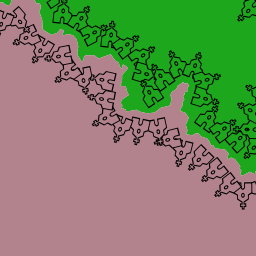

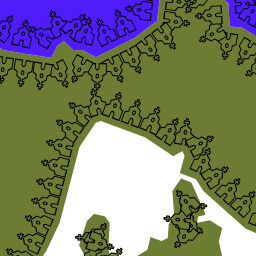

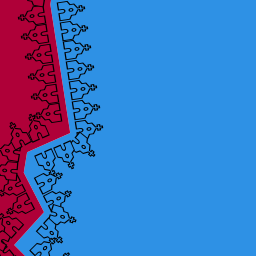

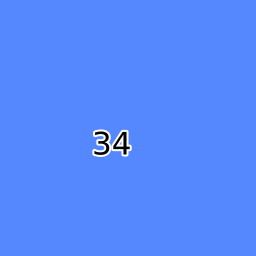

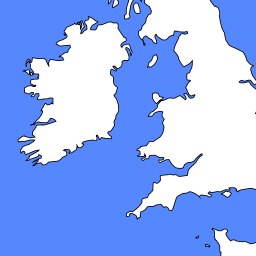

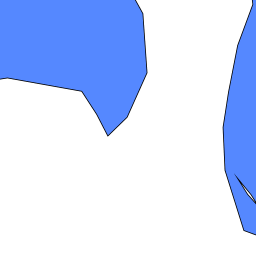

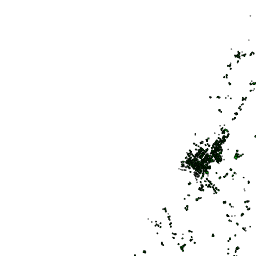

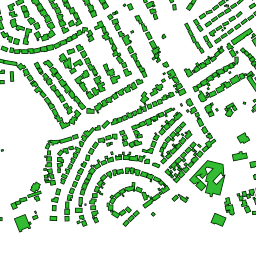

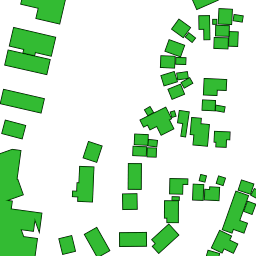

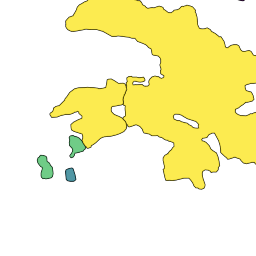

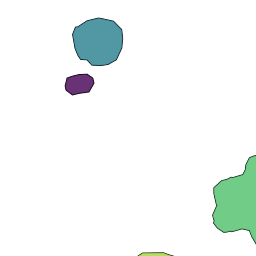

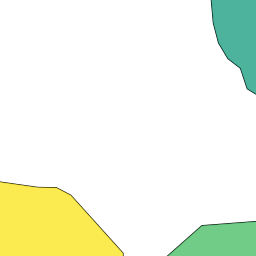

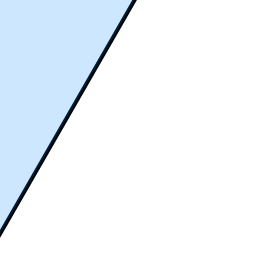

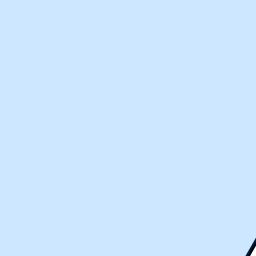

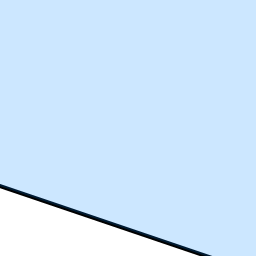

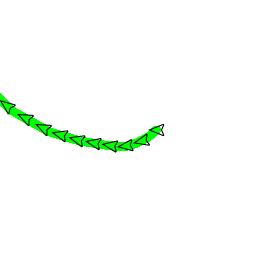

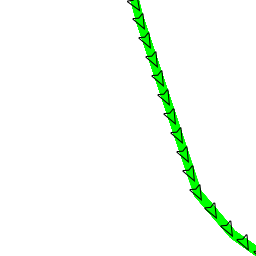

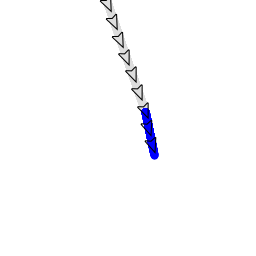

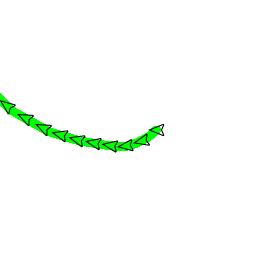

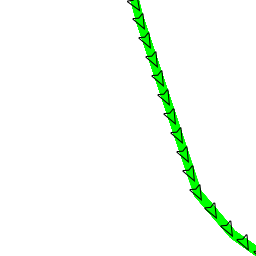

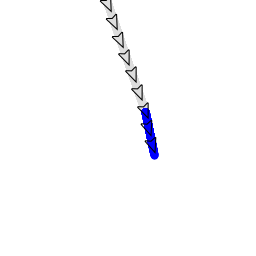

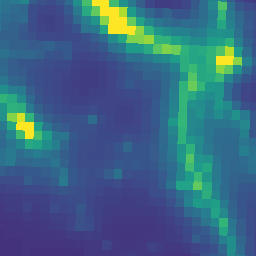

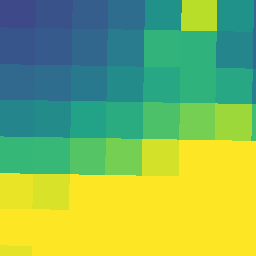

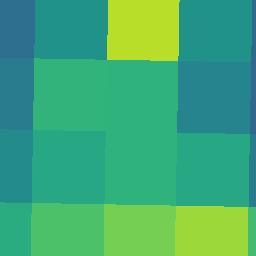

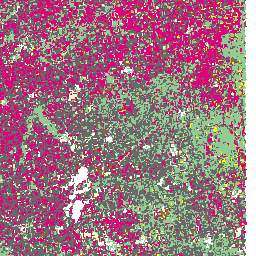

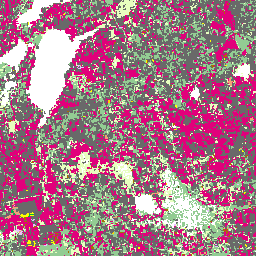

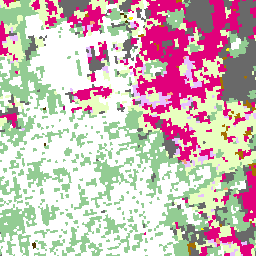

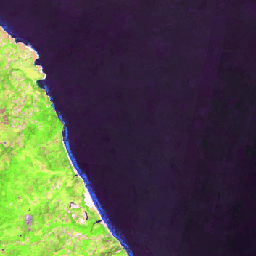

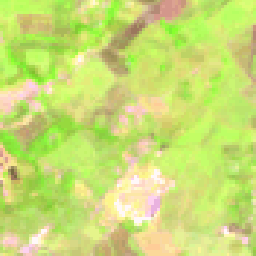

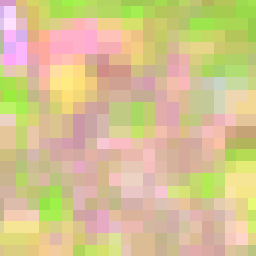

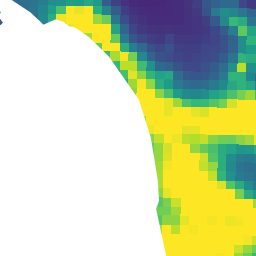

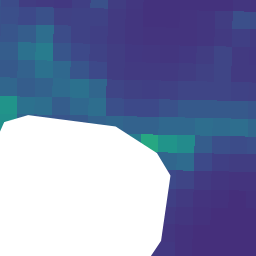

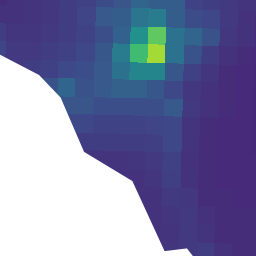

In [39]:
from urllib.request import urlopen
from PIL import Image

for url in test_tiles_url:
    img = Image.open(urlopen(url))
    display(img)
    print('')